# Phase 4 — Agent Training

Run every cell top to bottom. This notebook:
1. Trains a DQN agent and a PPO agent
2. Evaluates both on the validation set (2020-2021)
3. Plots reward curves, trade signals, and portfolio comparison
4. Prints a DQN vs PPO vs Buy & Hold comparison table

**Expected runtime:** ~5-15 minutes depending on your machine (CPU is fine for 200k steps).

---
## Cell 1 — Imports & path setup

In [4]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from env.trading_env import TradingEnv
import importlib
import data.pipeline as pipeline_mod
importlib.reload(pipeline_mod)
run_pipeline = pipeline_mod.run_pipeline

TICKER      = 'AAPL'
WINDOW_SIZE = 10
MODEL_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print('[PASS] All imports successful.')
print(f'       Models will be saved to: {MODEL_DIR}')

[PASS] All imports successful.
       Models will be saved to: /Users/abdulmoiz/Downloads/RL Trading Agent/models


---
## Cell 2 — Load data (scaled features + raw prices)

In [7]:
import os
import pandas as pd

TICKER = 'AAPL'

# --- Scaled features ---
train_df = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'train.csv'),
    index_col=0, parse_dates=True
)
val_df = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'val.csv'),
    index_col=0, parse_dates=True
)
test_df = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'test.csv'),
    index_col=0, parse_dates=True
)

# --- Raw un-scaled prices ---
raw_all = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data', 'raw', f'{TICKER}.csv'),
    index_col=0, parse_dates=True
)
if isinstance(raw_all.columns, pd.MultiIndex):
    raw_all.columns = raw_all.columns.get_level_values(0)

# Align raw splits to scaled splits by index
train_raw = raw_all.loc[train_df.index]
val_raw   = raw_all.loc[val_df.index]
test_raw  = raw_all.loc[test_df.index]

# Sanity checks
assert not train_df.isnull().values.any(),  'FAIL: NaNs in train_df'
assert (train_raw['Close'] > 0).all(),      'FAIL: Negative prices in train_raw'
assert len(train_df) == len(train_raw),     'FAIL: Row count mismatch train'
assert len(val_df)   == len(val_raw),       'FAIL: Row count mismatch val'

print(f'Train : {train_df.shape}  |  Val : {val_df.shape}  |  Test : {test_df.shape}')
print(f'Raw Close range: ${train_raw["Close"].min():.2f} → ${train_raw["Close"].max():.2f}')
print()
print('[PASS] All data loaded directly from CSV. No pipeline import needed.')

Train : (1713, 8)  |  Val : (505, 8)  |  Test : (752, 8)
Raw Close range: $11.87 → $70.79

[PASS] All data loaded directly from CSV. No pipeline import needed.


---
## Cell 3 — Build environments

In [8]:
def make_env(df, raw_df):
    def _init():
        env = TradingEnv(df, raw_df, window_size=WINDOW_SIZE)
        return Monitor(env)
    return _init

train_env = DummyVecEnv([make_env(train_df, train_raw)])
val_env   = DummyVecEnv([make_env(val_df,   val_raw)])

print(f'Train env obs shape : {train_env.observation_space.shape}')
print(f'Action space        : {train_env.action_space}')
print('[PASS] Environments built and wrapped in DummyVecEnv.')

Train env obs shape : (10, 8)
Action space        : Discrete(3)
[PASS] Environments built and wrapped in DummyVecEnv.


---
## Cell 4 — Train DQN

This will print live progress. Watch for the reward trending upward over episodes.
Training ~200k steps takes roughly 3-8 minutes on CPU.

In [9]:
# EvalCallback saves the best checkpoint automatically
stop_cb = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=10, min_evals=20, verbose=1
)
eval_cb_dqn = EvalCallback(
    val_env,
    best_model_save_path = os.path.join(MODEL_DIR, 'dqn_best'),
    log_path             = os.path.join(MODEL_DIR, 'dqn_logs'),
    eval_freq            = 5_000,
    n_eval_episodes      = 3,
    deterministic        = True,
    callback_after_eval  = stop_cb,
    verbose              = 1,
)

dqn_model = DQN(
    policy                  = 'MlpPolicy',
    env                     = train_env,
    learning_rate           = 1e-4,
    buffer_size             = 50_000,
    learning_starts         = 1_000,
    batch_size              = 64,
    gamma                   = 0.99,
    train_freq              = 4,
    target_update_interval  = 500,
    exploration_fraction    = 0.15,
    exploration_final_eps   = 0.05,
    verbose                 = 1,
)

print('Training DQN for 200,000 steps...')
dqn_model.learn(
    total_timesteps = 200_000,
    callback        = eval_cb_dqn,
    progress_bar    = True,
)

dqn_save = os.path.join(MODEL_DIR, f'dqn_{TICKER.lower()}')
dqn_model.save(dqn_save)
print(f'\n[PASS] DQN trained and saved → {dqn_save}.zip')

Using cpu device
Training DQN for 200,000 steps...


Eval num_timesteps=5000, episode_reward=0.24 +/- 0.00

Episode length: 494.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 494      |
|    mean_reward      | 0.239    |
| rollout/            |          |
|    exploration_rate | 0.842    |
| time/               |          |
|    total_timesteps  | 5000     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.65e-05 |
|    n_updates        | 999      |
----------------------------------


New best mean reward!

...

Eval num_timesteps=155000, episode_reward=0.59 +/- 0.00

Episode length: 494.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 494      |
|    mean_reward      | 0.589    |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 155000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.11e-05 |
|    n_updates        | 38499    |
----------------------------------


Stopping training because there was no new best model in the last 11 evaluations


[PASS] DQN trained and saved → /Users/abdulmoiz/Downloads/RL Trading Agent/models/dqn_aapl.zip


---
## Cell 5 — Train PPO

In [10]:
# Rebuild train_env — DQN training exhausted the old one
train_env = DummyVecEnv([make_env(train_df, train_raw)])

stop_cb2 = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=10, min_evals=20, verbose=1
)
eval_cb_ppo = EvalCallback(
    val_env,
    best_model_save_path = os.path.join(MODEL_DIR, 'ppo_best'),
    log_path             = os.path.join(MODEL_DIR, 'ppo_logs'),
    eval_freq            = 5_000,
    n_eval_episodes      = 3,
    deterministic        = True,
    callback_after_eval  = stop_cb2,
    verbose              = 1,
)

ppo_model = PPO(
    policy        = 'MlpPolicy',
    env           = train_env,
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
    verbose       = 1,
)

print('Training PPO for 200,000 steps...')
ppo_model.learn(
    total_timesteps = 200_000,
    callback        = eval_cb_ppo,
    progress_bar    = True,
)

ppo_save = os.path.join(MODEL_DIR, f'ppo_{TICKER.lower()}')
ppo_model.save(ppo_save)
print(f'\n[PASS] PPO trained and saved → {ppo_save}.zip')

Using cpu device
Training PPO for 200,000 steps...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.7e+03  |
|    ep_rew_mean     | 0.0572   |
| time/              |          |
|    fps             | 5726     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.7e+03     |
|    ep_rew_mean          | 0.0395      |
| time/                   |             |
|    fps                  | 3715        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010869495 |
|    clip_fraction        | 0.0836      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_varian

Eval num_timesteps=5000, episode_reward=0.02 +/- 0.00

Episode length: 494.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 494         |
|    mean_reward          | 0.0214      |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.009689171 |
|    clip_fraction        | 0.0669      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | 0.113       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0322     |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00852    |
|    value_loss           | 0.00272     |
-----------------------------------------


New best mean reward!

...

Eval num_timesteps=155000, episode_reward=0.85 +/- 0.00

Episode length: 494.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 494         |
|    mean_reward          | 0.853       |
| time/                   |             |
|    total_timesteps      | 155000      |
| train/                  |             |
|    approx_kl            | 0.007922538 |
|    clip_fraction        | 0.0695      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.527      |
|    explained_variance   | 0.949       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00536    |
|    n_updates            | 750         |
|    policy_gradient_loss | -0.0118     |
|    value_loss           | 9.73e-05    |
-----------------------------------------


Stopping training because there was no new best model in the last 11 evaluations


[PASS] PPO trained and saved → /Users/abdulmoiz/Downloads/RL Trading Agent/models/ppo_aapl.zip


---
## Cell 6 — Evaluate both agents on the validation set

In [11]:
def run_episode(model, df, raw_df, window_size=10, initial_balance=10_000):
    """Run one full deterministic episode. Returns env after completion."""
    env = TradingEnv(df, raw_df, initial_balance=initial_balance,
                     window_size=window_size)
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated
    return env

def compute_metrics(env, initial_balance=10_000):
    portfolio = pd.Series(env.portfolio_history)
    returns   = portfolio.pct_change().dropna()
    final     = portfolio.iloc[-1]
    ret_pct   = (final - initial_balance) / initial_balance * 100
    sharpe    = (returns.mean() / (returns.std() + 1e-8)) * np.sqrt(252)
    dd        = ((portfolio - portfolio.cummax()) / portfolio.cummax()).min() * 100
    tlog      = env.get_trade_log()
    n_trades  = len(tlog)
    if n_trades > 0 and 'action' in tlog.columns:
        sells    = tlog[tlog['action']=='SELL']
        avg_buy  = tlog[tlog['action']=='BUY']['price'].mean() if len(tlog[tlog['action']=='BUY']) > 0 else 0
        win_rate = (sells['price'] > avg_buy).mean() * 100 if len(sells) > 0 else 0
    else:
        win_rate = 0
    return {
        'final_value'  : round(final, 2),
        'total_return' : round(ret_pct, 2),
        'sharpe'       : round(float(sharpe), 3),
        'max_drawdown' : round(float(dd), 2),
        'n_trades'     : n_trades,
        'win_rate'     : round(win_rate, 1),
    }

print('Running DQN on validation set...')
dqn_env = run_episode(dqn_model, val_df, val_raw)
dqn_metrics = compute_metrics(dqn_env)

print('Running PPO on validation set...')
ppo_env = run_episode(ppo_model, val_df, val_raw)
ppo_metrics = compute_metrics(ppo_env)

# Buy & Hold baseline
bnh_start = val_raw['Close'].iloc[0]
bnh_end   = val_raw['Close'].iloc[-1]
bnh_return = (bnh_end / bnh_start - 1) * 100
bnh_series = 10_000 * (val_raw['Close'] / bnh_start)
bnh_returns = bnh_series.pct_change().dropna()
bnh_sharpe  = (bnh_returns.mean() / (bnh_returns.std() + 1e-8)) * np.sqrt(252)
bnh_dd      = ((bnh_series - bnh_series.cummax()) / bnh_series.cummax()).min() * 100

print('\n' + '='*62)
print(f"  {'Metric':<25} {'DQN':>10} {'PPO':>10} {'Buy&Hold':>10}")
print('='*62)
rows = [
    ('Final portfolio ($)', 'final_value',  f"{10_000*(1+bnh_return/100):,.0f}"),
    ('Total return (%)',    'total_return', f"{bnh_return:+.2f}"),
    ('Sharpe ratio',        'sharpe',       f"{bnh_sharpe:.3f}"),
    ('Max drawdown (%)',    'max_drawdown', f"{bnh_dd:.2f}"),
    ('Trades',              'n_trades',     'N/A'),
    ('Win rate (%)',        'win_rate',     'N/A'),
]
for label, key, bnh_val in rows:
    print(f"  {label:<25} {str(dqn_metrics[key]):>10} {str(ppo_metrics[key]):>10} {bnh_val:>10}")
print('='*62)

Running DQN on validation set...
Running PPO on validation set...

  Metric                           DQN        PPO   Buy&Hold
  Final portfolio ($)         17103.67   21858.84     24,000
  Total return (%)               71.04     118.59    +140.00
  Sharpe ratio                   1.301      1.617      1.356
  Max drawdown (%)              -16.74     -21.74     -31.43
  Trades                           224        416        N/A
  Win rate (%)                    80.0       20.0        N/A


---
## Cell 7 — Portfolio value comparison chart

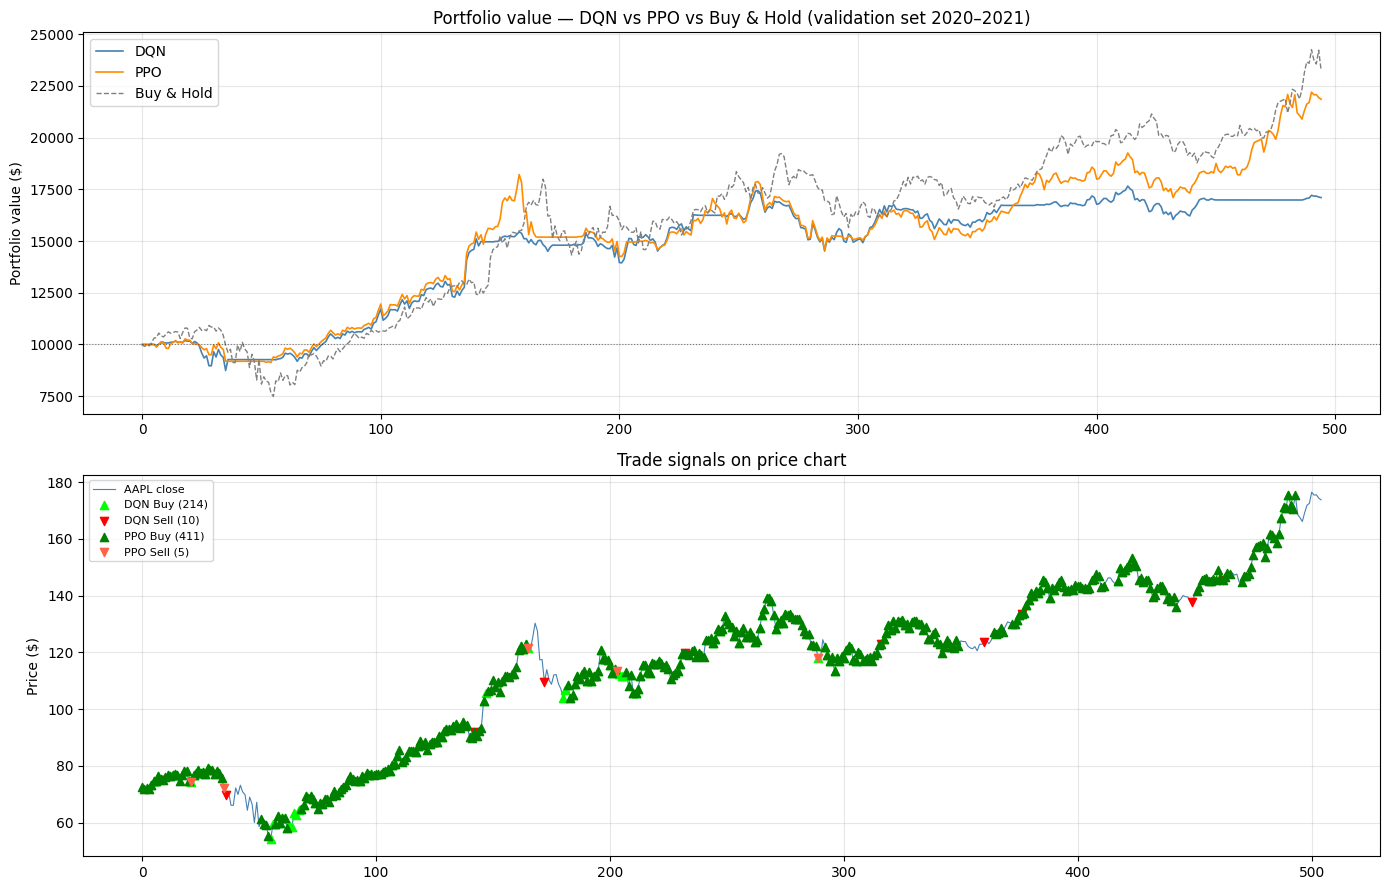

[PASS] Portfolio comparison chart rendered.


In [12]:
dqn_portfolio = pd.Series(dqn_env.portfolio_history)
ppo_portfolio = pd.Series(ppo_env.portfolio_history)
bnh_vals      = bnh_series.values[:max(len(dqn_portfolio), len(ppo_portfolio))]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Portfolio value
axes[0].plot(dqn_portfolio.values, label='DQN',        color='steelblue', linewidth=1.2)
axes[0].plot(ppo_portfolio.values, label='PPO',        color='darkorange', linewidth=1.2)
axes[0].plot(bnh_vals[:len(dqn_portfolio)],
             label='Buy & Hold', color='gray', linewidth=1, linestyle='--')
axes[0].axhline(10_000, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].set_title('Portfolio value — DQN vs PPO vs Buy & Hold (validation set 2020–2021)')
axes[0].set_ylabel('Portfolio value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Price chart with DQN trade signals
price_vals = val_raw['Close'].values
axes[1].plot(price_vals, color='steelblue', linewidth=0.8, label='AAPL close')

for env_obj, color_b, color_s, label in [
    (dqn_env, 'lime',   'red',    'DQN'),
    (ppo_env, 'green',  'tomato', 'PPO'),
]:
    tlog = env_obj.get_trade_log()
    if len(tlog) > 0:
        buys  = tlog[tlog['action']=='BUY']
        sells = tlog[tlog['action']=='SELL']
        buy_idx  = (buys['step'].values  - WINDOW_SIZE).clip(0, len(price_vals)-1)
        sell_idx = (sells['step'].values - WINDOW_SIZE).clip(0, len(price_vals)-1)
        axes[1].scatter(buy_idx,  price_vals[buy_idx],
                        marker='^', color=color_b, s=35, zorder=5,
                        label=f'{label} Buy ({len(buys)})')
        axes[1].scatter(sell_idx, price_vals[sell_idx],
                        marker='v', color=color_s, s=35, zorder=5,
                        label=f'{label} Sell ({len(sells)})')

axes[1].set_title('Trade signals on price chart')
axes[1].set_ylabel('Price ($)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('[PASS] Portfolio comparison chart rendered.')

---
## Cell 8 — Reward curve during training (from EvalCallback logs)

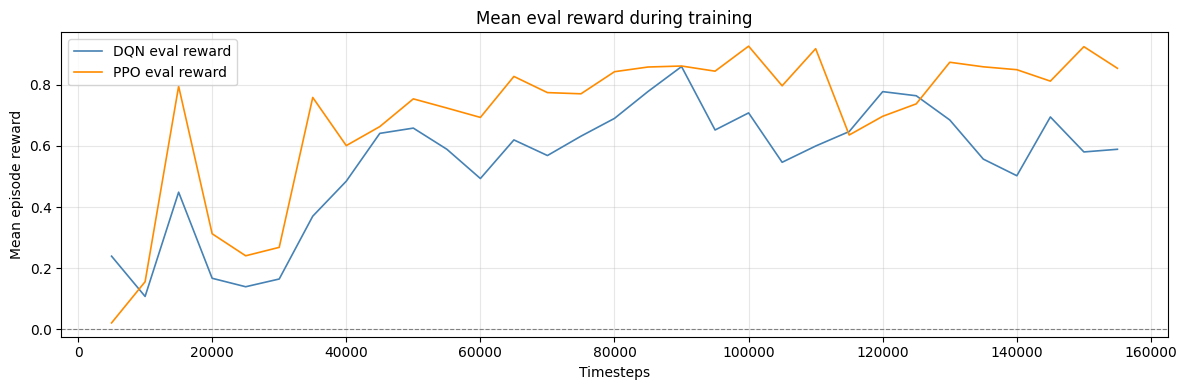

[PASS] Reward curves rendered.
[INFO] Healthy sign: reward trends upward over timesteps.


In [13]:
def load_eval_log(log_path):
    """Load EvalCallback evaluation log if it exists."""
    fpath = os.path.join(log_path, 'evaluations.npz')
    if not os.path.exists(fpath):
        return None, None
    data      = np.load(fpath)
    timesteps = data['timesteps']
    results   = data['results'].mean(axis=1)   # mean across eval episodes
    return timesteps, results

dqn_steps, dqn_rewards = load_eval_log(os.path.join(MODEL_DIR, 'dqn_logs'))
ppo_steps, ppo_rewards = load_eval_log(os.path.join(MODEL_DIR, 'ppo_logs'))

if dqn_steps is not None or ppo_steps is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    if dqn_steps is not None:
        ax.plot(dqn_steps, dqn_rewards, label='DQN eval reward',
                color='steelblue', linewidth=1.2)
    if ppo_steps is not None:
        ax.plot(ppo_steps, ppo_rewards, label='PPO eval reward',
                color='darkorange', linewidth=1.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title('Mean eval reward during training')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Mean episode reward')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('[PASS] Reward curves rendered.')
    print('[INFO] Healthy sign: reward trends upward over timesteps.')
else:
    print('[INFO] EvalCallback log files not found — skipping reward curve.')
    print('       This is fine if EvalCallback did not fire yet (< 5000 steps trained).')

---
## Cell 9 — Load saved models & verify (reload test)

In [14]:
dqn_path = os.path.join(MODEL_DIR, f'dqn_{TICKER.lower()}.zip')
ppo_path = os.path.join(MODEL_DIR, f'ppo_{TICKER.lower()}.zip')

assert os.path.exists(dqn_path), f'FAIL: DQN model not found at {dqn_path}'
assert os.path.exists(ppo_path), f'FAIL: PPO model not found at {ppo_path}'

# Reload from disk — simulates what the dashboard will do in Phase 6
dqn_reloaded = DQN.load(dqn_path)
ppo_reloaded = PPO.load(ppo_path)

# Quick prediction test
dummy_obs = np.zeros((1, WINDOW_SIZE, train_df.shape[1]), dtype=np.float32)
dqn_action, _ = dqn_reloaded.predict(dummy_obs, deterministic=True)
ppo_action, _ = ppo_reloaded.predict(dummy_obs, deterministic=True)

print(f'DQN model reloaded. Dummy obs → action: {dqn_action}')
print(f'PPO model reloaded. Dummy obs → action: {ppo_action}')
assert dqn_action[0] in [0, 1, 2], 'FAIL: DQN action out of range'
assert ppo_action[0] in [0, 1, 2], 'FAIL: PPO action out of range'
print()
print('[PASS] Both models save/load correctly. Ready for Phase 5 backtesting.')
print(f'       DQN: {os.path.getsize(dqn_path)/1024:.1f} KB')
print(f'       PPO: {os.path.getsize(ppo_path)/1024:.1f} KB')

DQN model reloaded. Dummy obs → action: [1]
PPO model reloaded. Dummy obs → action: [1]

[PASS] Both models save/load correctly. Ready for Phase 5 backtesting.
       DQN: 177.7 KB
       PPO: 254.8 KB


---
## Cell 10 — Phase 4 summary

In [15]:
print('='*55)
print('  Phase 4 — complete')
print('='*55)
print(f"  DQN model   : models/dqn_{TICKER.lower()}.zip")
print(f"  PPO model   : models/ppo_{TICKER.lower()}.zip")
print(f"  DQN return  : {dqn_metrics['total_return']:+.2f}%")
print(f"  PPO return  : {ppo_metrics['total_return']:+.2f}%")
print(f"  Buy & Hold  : {bnh_return:+.2f}%")
print()
best = 'DQN' if dqn_metrics['sharpe'] > ppo_metrics['sharpe'] else 'PPO'
print(f"  Best Sharpe : {best}")
print()
print('  Next: Phase 5 — backtest on the test set (2022-2024)')
print('        This is the first time the test set is touched.')
print('='*55)

  Phase 4 — complete
  DQN model   : models/dqn_aapl.zip
  PPO model   : models/ppo_aapl.zip
  DQN return  : +71.04%
  PPO return  : +118.59%
  Buy & Hold  : +140.00%

  Best Sharpe : PPO

  Next: Phase 5 — backtest on the test set (2022-2024)
        This is the first time the test set is touched.
